In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported!")

Libraries imported!


In [2]:
print("Please upload 2022_Annual_Client_Survey_Data.xlsx:")
up1 = files.upload()

print("\nPlease upload 2023_Annual_Client_Survey_Data.xlsx:")
up2 = files.upload()

print("\nPlease upload 2024_Annual_Client_Survey.xlsx:")
up3 = files.upload()

print("\nPlease upload Dempsey_Center_2025_Annual_Client_Survey.xlsx:")
up4 = files.upload()

print("\nAll files uploaded!")

Please upload 2022_Annual_Client_Survey_Data.xlsx:


Saving 2022 Annual Client Survey Data.xlsx to 2022 Annual Client Survey Data.xlsx

Please upload 2023_Annual_Client_Survey_Data.xlsx:


Saving 2023 Annual Client Survey Data.xlsx to 2023 Annual Client Survey Data.xlsx

Please upload 2024_Annual_Client_Survey.xlsx:


Saving 2024 Annual Client Survey.xlsx to 2024 Annual Client Survey.xlsx

Please upload Dempsey_Center_2025_Annual_Client_Survey.xlsx:


Saving Dempsey Center 2025 Annual Client Survey.xlsx to Dempsey Center 2025 Annual Client Survey.xlsx

All files uploaded!


In [5]:
files_dict = {
    '2022': '2022 Annual Client Survey Data.xlsx',
    '2023': '2023 Annual Client Survey Data.xlsx',
    '2024': '2024 Annual Client Survey.xlsx',
    '2025': 'Dempsey Center 2025 Annual Client Survey.xlsx'
}

for year, filename in files_dict.items():
    df = pd.read_excel(filename)
    print(f"{year}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"  First col: {df.columns[0][:70]}...")
    print(f"  Satisfaction col: {df.iloc[:, 0].value_counts().head(3)}")
    print()

2022: 270 rows, 72 columns
  First col: Overall, please rate your satisfaction with the services you received ...
  Satisfaction col: Overall, please rate your satisfaction with the services you received from the Dempsey Center.
Very Satisfied      200
Satisfied            45
Very Unsatisfied     12
Name: count, dtype: int64

2023: 299 rows, 85 columns
  First col: Overall, please rate your satisfaction with the services you received ...
  Satisfaction col: Overall, please rate your satisfaction with the services you received from the Dempsey Center in 2023.
Very Satisfied      223
Satisfied            33
Very Unsatisfied     23
Name: count, dtype: int64

2024: 294 rows, 95 columns
  First col: 1. Overall, please rate your satisfaction with the services you receiv...
  Satisfaction col: 1. Overall, please rate your satisfaction with the services you received from the Dempsey Center in 2024.
Very Satisfied      225
Satisfied            38
Very Unsatisfied     18
Name: count, dtype: int6

In [10]:
import pandas as pd

years = ['2022', '2023', '2024', '2025']
files = [
    '2022 Annual Client Survey Data.xlsx',
    '2023 Annual Client Survey Data.xlsx',
    '2024 Annual Client Survey.xlsx',
    'Dempsey Center 2025 Annual Client Survey.xlsx'
]

file_structures = {}

for year, filename in zip(years, files):
    print("\n" + "="*70)
    print(f"YEAR {year}: {filename}")
    print("="*70)

    df = pd.read_excel(filename)

    print(f"Shape: {df.shape}")
    print(f"\nALL {len(df.columns)} columns:")

    # Print ALL column names
    for i, col in enumerate(df.columns):
        col_str = str(col)[:100]
        print(f"{i:3d}. {col_str}")

    # Store structure
    file_structures[year] = {
        'filename': filename,
        'shape': df.shape,
        'columns': df.columns.tolist()
    }

    print(f"\nFirst 3 data rows (not header):")
    print(df.iloc[1:4, :5])


YEAR 2022: 2022 Annual Client Survey Data.xlsx
Shape: (270, 72)

ALL 72 columns:
  0. Overall, please rate your satisfaction with the services you received from the Dempsey Center.
  1. As a result of the services I received at the Dempsey Center, I feel that the following areas of my 
  2. Unnamed: 2
  3. Unnamed: 3
  4. Unnamed: 4
  5. Unnamed: 5
  6. Overall, did/does the Dempsey Center make your life better as it relates to your cancer impact?
  7. Which Dempsey Center Services have you used in 2022? (Select all that apply.)
  8. Unnamed: 8
  9. Unnamed: 9
 10. Unnamed: 10
 11. Unnamed: 11
 12. Unnamed: 12
 13. Unnamed: 13
 14. Unnamed: 14
 15. Unnamed: 15
 16. Unnamed: 16
 17. Unnamed: 17
 18. Unnamed: 18
 19. Unnamed: 19
 20. Unnamed: 20
 21. Unnamed: 21
 22. Unnamed: 22
 23. Unnamed: 23
 24. Unnamed: 24
 25. Unnamed: 25
 26. Unnamed: 26
 27. How often did you utilize services in 2022?
 28. Did any of the following negatively affect your ability to access Dempsey Center services

In [11]:
# Column mapping for each year (verified)
COLUMN_MAP = {
    '2022': {
        'satisfaction': 0,
        'life_better': 6,
        'service_freq': 27,
        'cancer_status': 43,
        'treatment_stage': 45,
        'age': 47,
        'gender': 49,
        'income': None,
        'household_size': None
    },
    '2023': {
        'satisfaction': 0,
        'life_better': 1,
        'service_freq': 22,
        'cancer_status': 50,
        'treatment_stage': 52,
        'age': 54,
        'gender': 57,
        'income': 56,
        'household_size': None
    },
    '2024': {
        'satisfaction': 0,
        'life_better': 1,
        'service_freq': 34,
        'cancer_status': 63,
        'treatment_stage': 65,
        'age': 67,
        'gender': 71,
        'income': 69,
        'household_size': 70
    },
    '2025': {
        'satisfaction': 4,
        'life_better': 5,
        'service_freq': 38,
        'cancer_status': 68,
        'treatment_stage': 70,
        'age': 74,
        'gender': 78,
        'income': 76,
        'household_size': 77
    }
}

print("Column mappings created!")
print("\nMapping structure:")
for year in ['2022', '2023', '2024', '2025']:
    print(f"{year}: Satisfaction=Col{COLUMN_MAP[year]['satisfaction']}, Age=Col{COLUMN_MAP[year]['age']}")

Column mappings created!

Mapping structure:
2022: Satisfaction=Col0, Age=Col47
2023: Satisfaction=Col0, Age=Col54
2024: Satisfaction=Col0, Age=Col67
2025: Satisfaction=Col4, Age=Col74


In [12]:
# Extract data from all 4 years using verified column positions
def extract_year_data(filename, year):
    df = pd.read_excel(filename)
    col_map = COLUMN_MAP[year]

    # Skip first row (header with "Response")
    data = {
        'Year': year,
        'Satisfaction': df.iloc[1:, col_map['satisfaction']],
        'LifeBetter': df.iloc[1:, col_map['life_better']],
        'Age': df.iloc[1:, col_map['age']],
        'Gender': df.iloc[1:, col_map['gender']]
    }

    # Add optional columns if they exist
    if col_map['service_freq'] is not None:
        data['ServiceFreq'] = df.iloc[1:, col_map['service_freq']]

    if col_map['cancer_status'] is not None:
        data['CancerStatus'] = df.iloc[1:, col_map['cancer_status']]

    if col_map['treatment_stage'] is not None:
        data['TreatmentStage'] = df.iloc[1:, col_map['treatment_stage']]

    if col_map['income'] is not None:
        data['Income'] = df.iloc[1:, col_map['income']]

    result = pd.DataFrame(data)
    return result.reset_index(drop=True)

# Extract all years
all_years = []
for year, filename in files_dict.items():
    df_year = extract_year_data(filename, year)
    all_years.append(df_year)
    print(f"{year}: {len(df_year)} rows extracted")

# Combine
df_all = pd.concat(all_years, ignore_index=True)

print(f"\nTotal combined: {len(df_all)} rows")
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nSample data:")
print(df_all.head())

2022: 269 rows extracted
2023: 298 rows extracted
2024: 293 rows extracted
2025: 319 rows extracted

Total combined: 1179 rows

Columns: ['Year', 'Satisfaction', 'LifeBetter', 'Age', 'Gender', 'ServiceFreq', 'CancerStatus', 'TreatmentStage', 'Income']

Sample data:
   Year    Satisfaction LifeBetter          Age                     Gender  \
0  2022  Very Satisfied        Yes        65-74  Woman / Female / Feminine   
1  2022  Very Satisfied        Yes        55-64  Woman / Female / Feminine   
2  2022  Very Satisfied        Yes  75 or older  Woman / Female / Feminine   
3  2022  Very Satisfied        Yes        55-64  Woman / Female / Feminine   
4  2022  Very Satisfied        Yes        65-74  Woman / Female / Feminine   

          ServiceFreq             CancerStatus          TreatmentStage Income  
0           6-9 times        I have had cancer  No Evidence of Disease    NaN  
1              1 time        I have had cancer          Post-treatment    NaN  
2  More than 10 times    

In [14]:
# Data cleaning
df_clean = df_all.copy()

# Remove any remaining 'Response' rows
df_clean = df_clean[df_clean['Satisfaction'] != 'Response']
df_clean = df_clean[df_clean['LifeBetter'] != 'Response']

# Standardize Gender
df_clean['Gender'] = df_clean['Gender'].replace({
    'Woman / Female / Feminine': 'Woman',
    'Man / Male / Masculine': 'Man',
    'Prefer not to say': 'Prefer not to answer'
})

# Remove rows with missing core data
df_clean = df_clean.dropna(subset=['Satisfaction', 'LifeBetter', 'Age', 'Gender'])

# Create binary target variable for ML
df_clean['HighSatisfaction'] = (df_clean['Satisfaction'] == 'Very Satisfied').astype(int)

# Clean Age categories
df_clean = df_clean[~df_clean['Age'].isin(['Response', 'Prefer not to answer'])]

# Clean Gender
df_clean = df_clean[~df_clean['Gender'].isin(['Response', 'Prefer not to answer',
                                                'Other / Prefer to self-describe'])]

print(f"After cleaning: {len(df_clean)} rows (from {len(df_all)})")
print(f"Removed: {len(df_all) - len(df_clean)} rows")

print(f"\nFinal data summary:")
print(f"  By Year: {df_clean['Year'].value_counts().sort_index().to_dict()}")
print(f"  Satisfaction: {df_clean['Satisfaction'].value_counts().to_dict()}")
print(f"  High Satisfaction rate: {df_clean['HighSatisfaction'].mean():.2%}")

# Save cleaned data
df_clean.to_csv('dempsey_cleaned_data.csv', index=False)
print("\nData saved to dempsey_cleaned_data.csv")

After cleaning: 1047 rows (from 1179)
Removed: 132 rows

Final data summary:
  By Year: {'2022': 257, '2023': 262, '2024': 252, '2025': 276}
  Satisfaction: {'Very Satisfied': 802, 'Satisfied': 142, 'Very Unsatisfied': 60, 'Neither Satisfied nor Unsatisfied': 29, 'Unsatisfied': 14}
  High Satisfaction rate: 76.60%

Data saved to dempsey_cleaned_data.csv


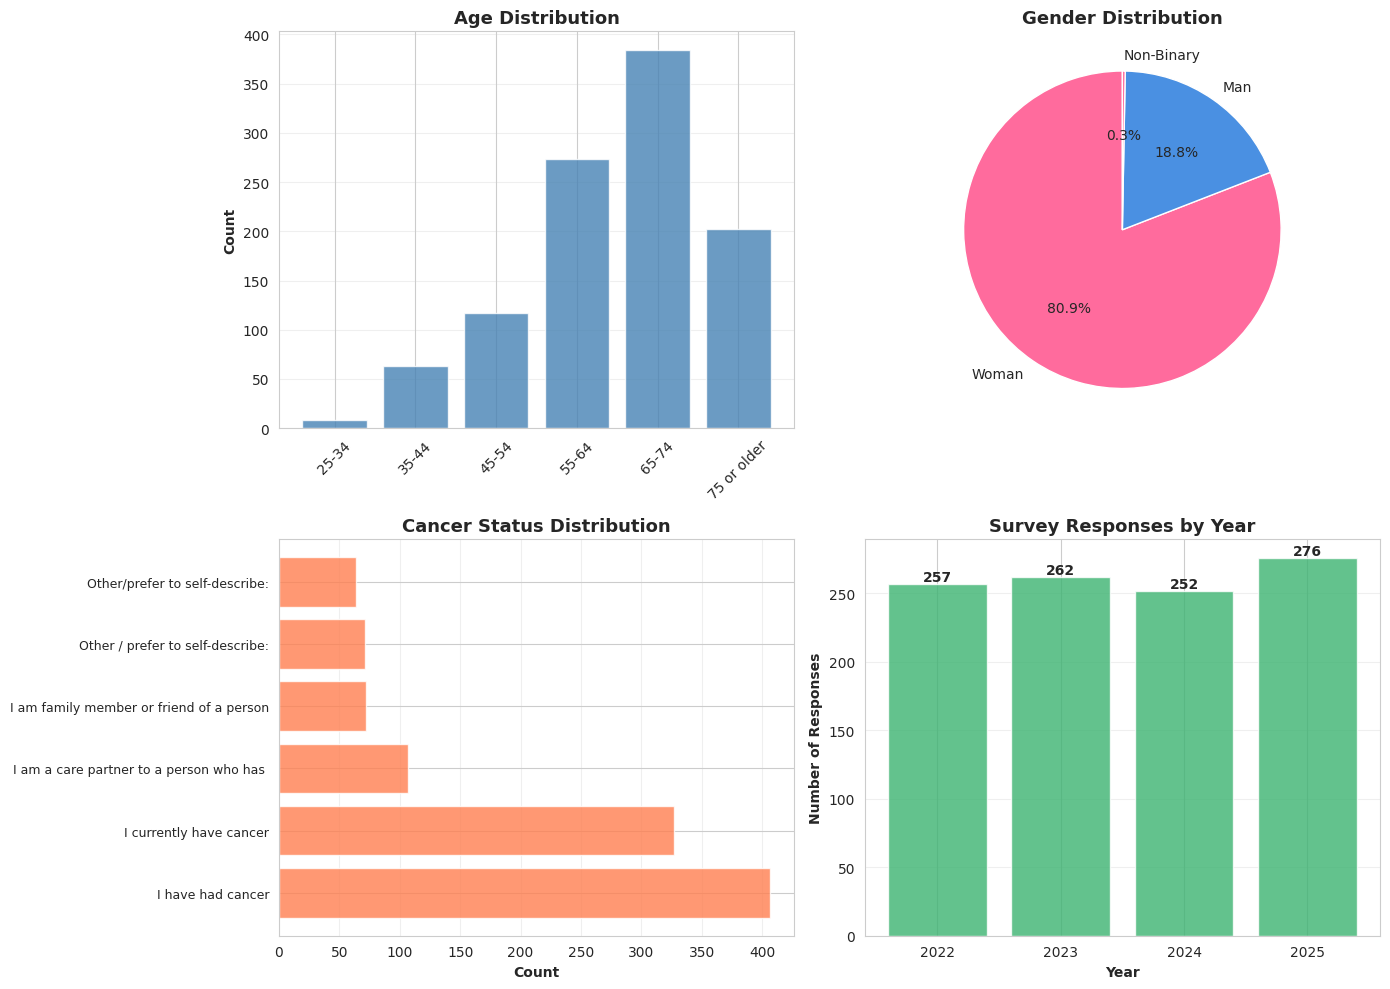

In [15]:
# EDA Part 1: Demographics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
ax = axes[0, 0]
age_counts = df_clean['Age'].value_counts()
age_order = ['25-34', '35-44', '45-54', '55-64', '65-74', '75 or older']
age_counts = age_counts.reindex([a for a in age_order if a in age_counts.index])
ax.bar(range(len(age_counts)), age_counts.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(age_counts)))
ax.set_xticklabels(age_counts.index, rotation=45)
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Age Distribution', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)

# Gender distribution
ax = axes[0, 1]
gender_counts = df_clean['Gender'].value_counts()
colors_gender = ['#FF6B9D', '#4A90E2']
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=colors_gender, startangle=90)
ax.set_title('Gender Distribution', fontweight='bold', fontsize=13)

# Cancer Status
ax = axes[1, 0]
cancer_counts = df_clean['CancerStatus'].value_counts().head(6)
ax.barh(range(len(cancer_counts)), cancer_counts.values, color='coral', alpha=0.8)
ax.set_yticks(range(len(cancer_counts)))
ax.set_yticklabels([s[:40] for s in cancer_counts.index], fontsize=9)
ax.set_xlabel('Count', fontweight='bold')
ax.set_title('Cancer Status Distribution', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

# Responses by year
ax = axes[1, 1]
year_counts = df_clean['Year'].value_counts().sort_index()
bars = ax.bar(year_counts.index, year_counts.values, color='mediumseagreen', alpha=0.8)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Number of Responses', fontweight='bold')
ax.set_title('Survey Responses by Year', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_demographics.png', dpi=300, bbox_inches='tight')
plt.show()

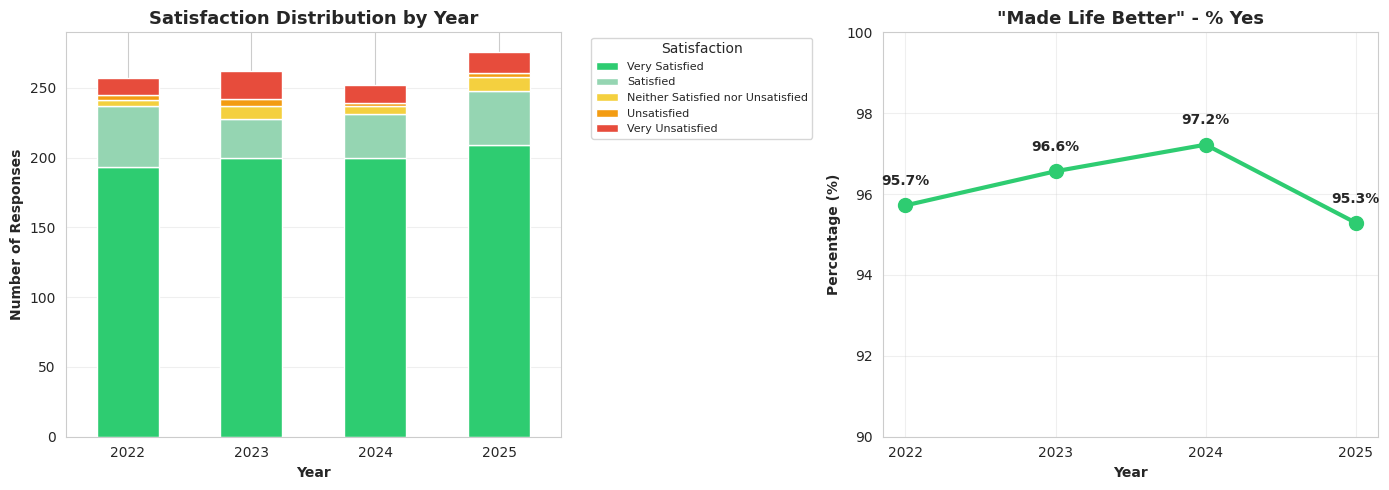

Satisfaction by year:
Satisfaction  Very Satisfied  Satisfied  Neither Satisfied nor Unsatisfied  \
Year                                                                         
2022                     193         44                                  4   
2023                     200         28                                  9   
2024                     200         31                                  6   
2025                     209         39                                 10   

Satisfaction  Unsatisfied  Very Unsatisfied  
Year                                         
2022                    4                12  
2023                    5                20  
2024                    2                13  
2025                    3                15  

'Made Life Better' Yes %:
Year
2022    95.719844
2023    96.564885
2024    97.222222
2025    95.289855
Name: Yes, dtype: float64


In [16]:
# EDA Part 2: Satisfaction Trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction by year (stacked)
ax = axes[0]
sat_year = df_clean.groupby(['Year', 'Satisfaction']).size().unstack(fill_value=0)
sat_order = ['Very Satisfied', 'Satisfied', 'Neither Satisfied nor Unsatisfied',
             'Unsatisfied', 'Very Unsatisfied']
sat_year = sat_year[[col for col in sat_order if col in sat_year.columns]]
sat_year.plot(kind='bar', stacked=True, ax=ax,
              color=['#2ECC71', '#95D5B2', '#F4D03F', '#F39C12', '#E74C3C'])
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Number of Responses', fontweight='bold')
ax.set_title('Satisfaction Distribution by Year', fontweight='bold', fontsize=13)
ax.legend(title='Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

# "Made Life Better" trend
ax = axes[1]
life_year = df_clean.groupby(['Year', 'LifeBetter']).size().unstack(fill_value=0)
life_pct = life_year.div(life_year.sum(axis=1), axis=0) * 100
yes_pct = life_pct['Yes']

ax.plot(yes_pct.index, yes_pct.values, marker='o', linewidth=3,
        markersize=10, color='#2ECC71')
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_title('"Made Life Better" - % Yes', fontweight='bold', fontsize=13)
ax.set_ylim([90, 100])
ax.grid(alpha=0.3)
for x, y in zip(yes_pct.index, yes_pct.values):
    ax.text(x, y+0.5, f'{y:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_satisfaction_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("Satisfaction by year:")
print(sat_year)
print(f"\n'Made Life Better' Yes %:")
print(yes_pct)

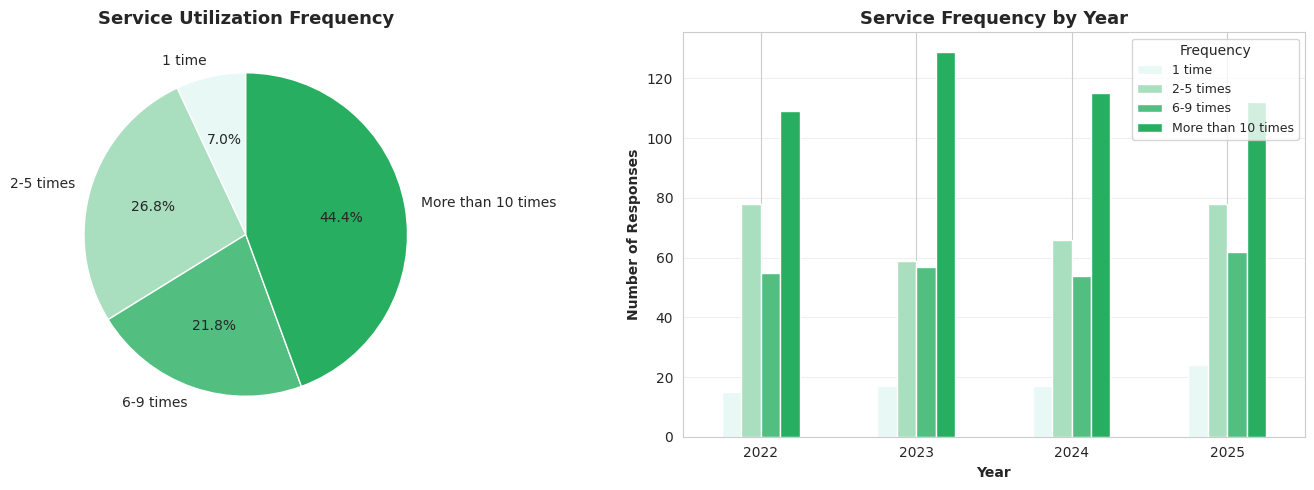

Service frequency data available for 1047 responses

Frequency distribution:
ServiceFreq
1 time                 73
2-5 times             281
6-9 times             228
More than 10 times    465
Name: count, dtype: int64


In [17]:
# EDA Part 3: Service Frequency Analysis
df_with_freq = df_clean[df_clean['ServiceFreq'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall service frequency distribution
ax = axes[0]
freq_counts = df_with_freq['ServiceFreq'].value_counts()
freq_order = ['1 time', '2-5 times', '6-9 times', 'More than 10 times']
freq_counts = freq_counts.reindex([f for f in freq_order if f in freq_counts.index])

colors_freq = ['#E8F8F5', '#A9DFBF', '#52BE80', '#27AE60']
ax.pie(freq_counts.values, labels=freq_counts.index, autopct='%1.1f%%',
       colors=colors_freq, startangle=90)
ax.set_title('Service Utilization Frequency', fontweight='bold', fontsize=13)

# Frequency by year
ax = axes[1]
freq_year = df_with_freq.groupby(['Year', 'ServiceFreq']).size().unstack(fill_value=0)
freq_year = freq_year[[f for f in freq_order if f in freq_year.columns]]
freq_year.plot(kind='bar', ax=ax, color=colors_freq)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Number of Responses', fontweight='bold')
ax.set_title('Service Frequency by Year', fontweight='bold', fontsize=13)
ax.legend(title='Frequency', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('fig3_service_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Service frequency data available for {len(df_with_freq)} responses")
print(f"\nFrequency distribution:")
print(freq_counts)

In [18]:
# Statistical Tests: Chi-square
from scipy.stats import chi2_contingency

print("CHI-SQUARE TESTS")
print("="*70)

# Test 1: Cancer Status vs Satisfaction
df_test1 = df_clean[df_clean['CancerStatus'].notna()].copy()
contingency1 = pd.crosstab(df_test1['CancerStatus'], df_test1['HighSatisfaction'])
chi2_1, p1, dof1, expected1 = chi2_contingency(contingency1)

print("\n1. Cancer Status vs High Satisfaction")
print(f"   Chi-square statistic: {chi2_1:.4f}")
print(f"   p-value: {p1:.4f}")
print(f"   Result: {'Significant' if p1 < 0.05 else 'Not significant'} (p < 0.05)")

# Test 2: Age vs Satisfaction
contingency2 = pd.crosstab(df_clean['Age'], df_clean['HighSatisfaction'])
chi2_2, p2, dof2, expected2 = chi2_contingency(contingency2)

print("\n2. Age vs High Satisfaction")
print(f"   Chi-square statistic: {chi2_2:.4f}")
print(f"   p-value: {p2:.4f}")
print(f"   Result: {'Significant' if p2 < 0.05 else 'Not significant'} (p < 0.05)")

# Test 3: Service Frequency vs Satisfaction
df_test3 = df_clean[df_clean['ServiceFreq'].notna()].copy()
contingency3 = pd.crosstab(df_test3['ServiceFreq'], df_test3['HighSatisfaction'])
chi2_3, p3, dof3, expected3 = chi2_contingency(contingency3)

print("\n3. Service Frequency vs High Satisfaction")
print(f"   Chi-square statistic: {chi2_3:.4f}")
print(f"   p-value: {p3:.4f}")
print(f"   Result: {'Significant' if p3 < 0.05 else 'Not significant'} (p < 0.05)")

# Store results
chi_results = pd.DataFrame({
    'Test': ['Cancer Status vs Satisfaction', 'Age vs Satisfaction',
             'Service Frequency vs Satisfaction'],
    'Chi-square': [chi2_1, chi2_2, chi2_3],
    'p-value': [p1, p2, p3],
    'Significant': [p1 < 0.05, p2 < 0.05, p3 < 0.05]
})

print("\n" + "="*70)
print("Summary Table:")
print(chi_results)

CHI-SQUARE TESTS

1. Cancer Status vs High Satisfaction
   Chi-square statistic: 7.7295
   p-value: 0.1718
   Result: Not significant (p < 0.05)

2. Age vs High Satisfaction
   Chi-square statistic: 13.1814
   p-value: 0.0217
   Result: Significant (p < 0.05)

3. Service Frequency vs High Satisfaction
   Chi-square statistic: 66.0458
   p-value: 0.0000
   Result: Significant (p < 0.05)

Summary Table:
                                Test  Chi-square       p-value  Significant
0      Cancer Status vs Satisfaction    7.729550  1.717840e-01        False
1                Age vs Satisfaction   13.181413  2.173677e-02         True
2  Service Frequency vs Satisfaction   66.045787  2.996640e-14         True


In [19]:
# ML Classification: Prepare data
# Only use rows with complete data
df_ml = df_clean[['Age', 'Gender', 'ServiceFreq', 'CancerStatus', 'HighSatisfaction']].copy()
df_ml = df_ml.dropna()

print(f"ML dataset: {len(df_ml)} rows")

# Encode categorical variables
le_age = LabelEncoder()
le_gender = LabelEncoder()
le_freq = LabelEncoder()
le_cancer = LabelEncoder()

df_ml['Age_encoded'] = le_age.fit_transform(df_ml['Age'])
df_ml['Gender_encoded'] = le_gender.fit_transform(df_ml['Gender'])
df_ml['Freq_encoded'] = le_freq.fit_transform(df_ml['ServiceFreq'])
df_ml['Cancer_encoded'] = le_cancer.fit_transform(df_ml['CancerStatus'])

# Features and target
X = df_ml[['Age_encoded', 'Gender_encoded', 'Freq_encoded', 'Cancer_encoded']].values
y = df_ml['HighSatisfaction'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'model': model,
        'predictions': y_pred
    }
    print(f"{name}: {acc:.4f}")

print(f"\nBest model: {max(results, key=lambda k: results[k]['accuracy'])}")

ML dataset: 1047 rows
Decision Tree: 0.7206
Random Forest: 0.7206
KNN (k=3): 0.6794

Best model: Decision Tree


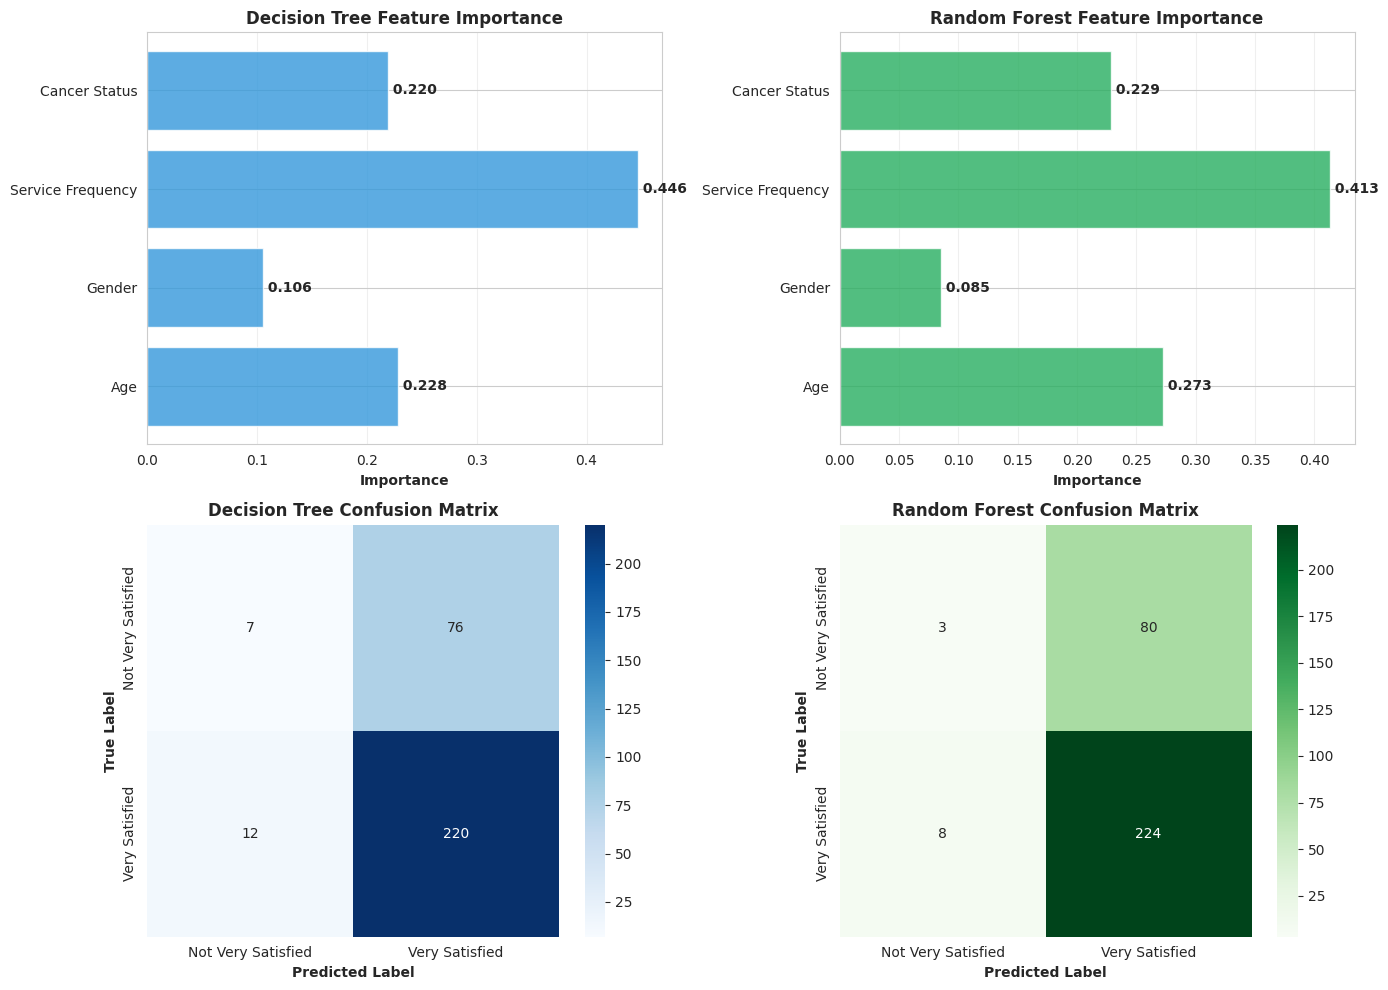

Feature Importance Rankings:

Decision Tree:
  1. Age: 0.228
  2. Gender: 0.106
  3. Service Frequency: 0.446
  4. Cancer Status: 0.220

Random Forest:
  1. Age: 0.273
  2. Gender: 0.085
  3. Service Frequency: 0.413
  4. Cancer Status: 0.229


In [20]:
# Feature Importance and Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Decision Tree Feature Importance
ax = axes[0, 0]
dt_model = results['Decision Tree']['model']
feature_names = ['Age', 'Gender', 'Service Frequency', 'Cancer Status']
importances_dt = dt_model.feature_importances_

bars = ax.barh(feature_names, importances_dt, color='#3498DB', alpha=0.8)
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Decision Tree Feature Importance', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(importances_dt):
    ax.text(v, i, f' {v:.3f}', va='center', fontweight='bold')

# Random Forest Feature Importance
ax = axes[0, 1]
rf_model = results['Random Forest']['model']
importances_rf = rf_model.feature_importances_

bars = ax.barh(feature_names, importances_rf, color='#27AE60', alpha=0.8)
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Random Forest Feature Importance', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(importances_rf):
    ax.text(v, i, f' {v:.3f}', va='center', fontweight='bold')

# Decision Tree Confusion Matrix
ax = axes[1, 0]
cm_dt = confusion_matrix(y_test, results['Decision Tree']['predictions'])
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Very Satisfied', 'Very Satisfied'],
            yticklabels=['Not Very Satisfied', 'Very Satisfied'])
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_title('Decision Tree Confusion Matrix', fontweight='bold', fontsize=12)

# Random Forest Confusion Matrix
ax = axes[1, 1]
cm_rf = confusion_matrix(y_test, results['Random Forest']['predictions'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Not Very Satisfied', 'Very Satisfied'],
            yticklabels=['Not Very Satisfied', 'Very Satisfied'])
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_title('Random Forest Confusion Matrix', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('fig4_ml_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature Importance Rankings:")
print("\nDecision Tree:")
for i, (feat, imp) in enumerate(zip(feature_names, importances_dt)):
    print(f"  {i+1}. {feat}: {imp:.3f}")
print("\nRandom Forest:")
for i, (feat, imp) in enumerate(zip(feature_names, importances_rf)):
    print(f"  {i+1}. {feat}: {imp:.3f}")

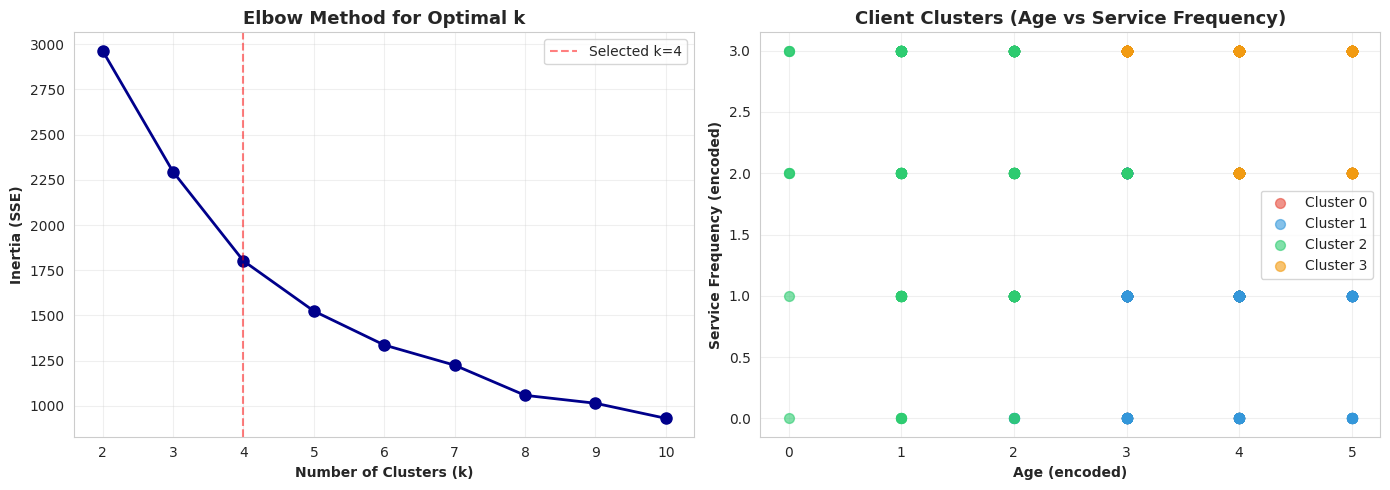

Cluster Characteristics:

Cluster 0 (n=146):
  Most common age: 65-74
  Most common frequency: More than 10 times
  High satisfaction rate: 76.03%

Cluster 1 (n=281):
  Most common age: 55-64
  Most common frequency: 2-5 times
  High satisfaction rate: 65.12%

Cluster 2 (n=187):
  Most common age: 45-54
  Most common frequency: More than 10 times
  High satisfaction rate: 73.80%

Cluster 3 (n=433):
  Most common age: 65-74
  Most common frequency: More than 10 times
  High satisfaction rate: 85.45%


In [21]:
# K-means Clustering
# Use Age, Service Frequency, Cancer Status for clustering
df_cluster = df_ml[['Age_encoded', 'Freq_encoded', 'Cancer_encoded']].copy()

# Elbow method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster)
    inertias.append(kmeans.inertia_)

# Plot elbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='darkblue')
ax.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax.set_ylabel('Inertia (SSE)', fontweight='bold')
ax.set_title('Elbow Method for Optimal k', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Selected k=4')
ax.legend()

# Run K-means with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans_final.fit_predict(df_cluster)

# Visualize clusters (2D projection using first 2 features)
ax = axes[1]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
for i in range(4):
    cluster_data = df_cluster[df_cluster['Cluster'] == i]
    ax.scatter(cluster_data['Age_encoded'], cluster_data['Freq_encoded'],
              label=f'Cluster {i}', alpha=0.6, s=50, c=colors[i])

ax.set_xlabel('Age (encoded)', fontweight='bold')
ax.set_ylabel('Service Frequency (encoded)', fontweight='bold')
ax.set_title('Client Clusters (Age vs Service Frequency)', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyze cluster characteristics
df_ml['Cluster'] = df_cluster['Cluster']
print("Cluster Characteristics:")
for i in range(4):
    cluster_i = df_ml[df_ml['Cluster'] == i]
    print(f"\nCluster {i} (n={len(cluster_i)}):")
    print(f"  Most common age: {cluster_i['Age'].mode()[0]}")
    print(f"  Most common frequency: {cluster_i['ServiceFreq'].mode()[0]}")
    print(f"  High satisfaction rate: {cluster_i['HighSatisfaction'].mean():.2%}")

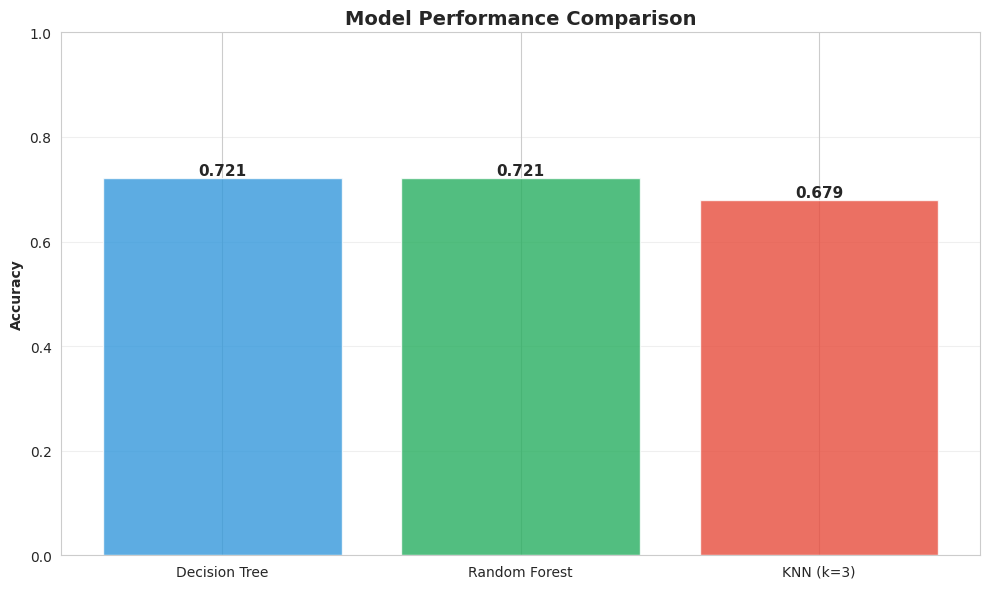

Model accuracies:
  Decision Tree: 0.7206
  Random Forest: 0.7206
  KNN (k=3): 0.6794


In [22]:
# Additional Analysis 1: Model Accuracy Comparison (like HW6)
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

bars = ax.bar(model_names, accuracies, color=['#3498DB', '#27AE60', '#E74C3C'], alpha=0.8)
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model accuracies:")
for name, acc in zip(model_names, accuracies):
    print(f"  {name}: {acc:.4f}")

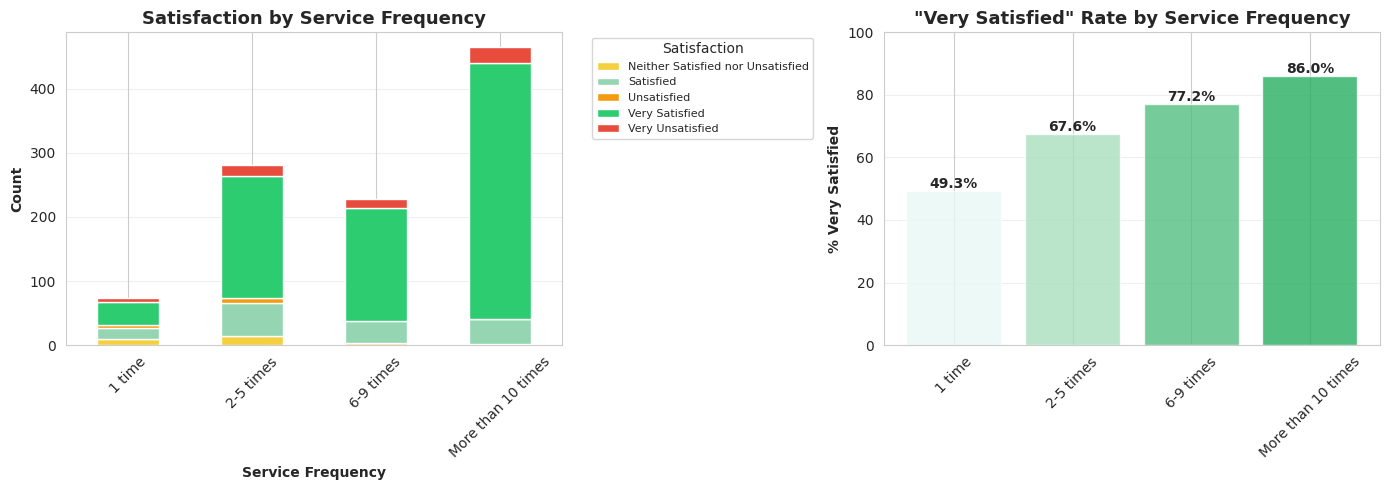

High Satisfaction % by Frequency:
ServiceFreq
1 time                49.315068
2-5 times             67.615658
6-9 times             77.192982
More than 10 times    86.021505
Name: HighSatisfaction, dtype: float64


In [23]:
# Additional Analysis 2: Service Frequency vs Satisfaction breakdown
df_freq_sat = df_clean[df_clean['ServiceFreq'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar showing satisfaction by frequency
ax = axes[0]
freq_sat = pd.crosstab(df_freq_sat['ServiceFreq'], df_freq_sat['Satisfaction'])
freq_order = ['1 time', '2-5 times', '6-9 times', 'More than 10 times']
freq_sat = freq_sat.reindex(freq_order)

sat_colors = {'Very Satisfied': '#2ECC71', 'Satisfied': '#95D5B2',
              'Neither Satisfied nor Unsatisfied': '#F4D03F',
              'Unsatisfied': '#F39C12', 'Very Unsatisfied': '#E74C3C'}
colors_list = [sat_colors.get(col, 'gray') for col in freq_sat.columns]

freq_sat.plot(kind='bar', stacked=True, ax=ax, color=colors_list)
ax.set_xlabel('Service Frequency', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Satisfaction by Service Frequency', fontweight='bold', fontsize=13)
ax.legend(title='Satisfaction', bbox_to_anchor=(1.05, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# High satisfaction percentage by frequency
ax = axes[1]
high_sat_pct = df_freq_sat.groupby('ServiceFreq')['HighSatisfaction'].mean() * 100
high_sat_pct = high_sat_pct.reindex(freq_order)

bars = ax.bar(range(len(high_sat_pct)), high_sat_pct.values,
              color=['#E8F8F5', '#A9DFBF', '#52BE80', '#27AE60'], alpha=0.8)
ax.set_xticks(range(len(high_sat_pct)))
ax.set_xticklabels(high_sat_pct.index, rotation=45)
ax.set_ylabel('% Very Satisfied', fontweight='bold')
ax.set_title('"Very Satisfied" Rate by Service Frequency', fontweight='bold', fontsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_frequency_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

print("High Satisfaction % by Frequency:")
print(high_sat_pct)

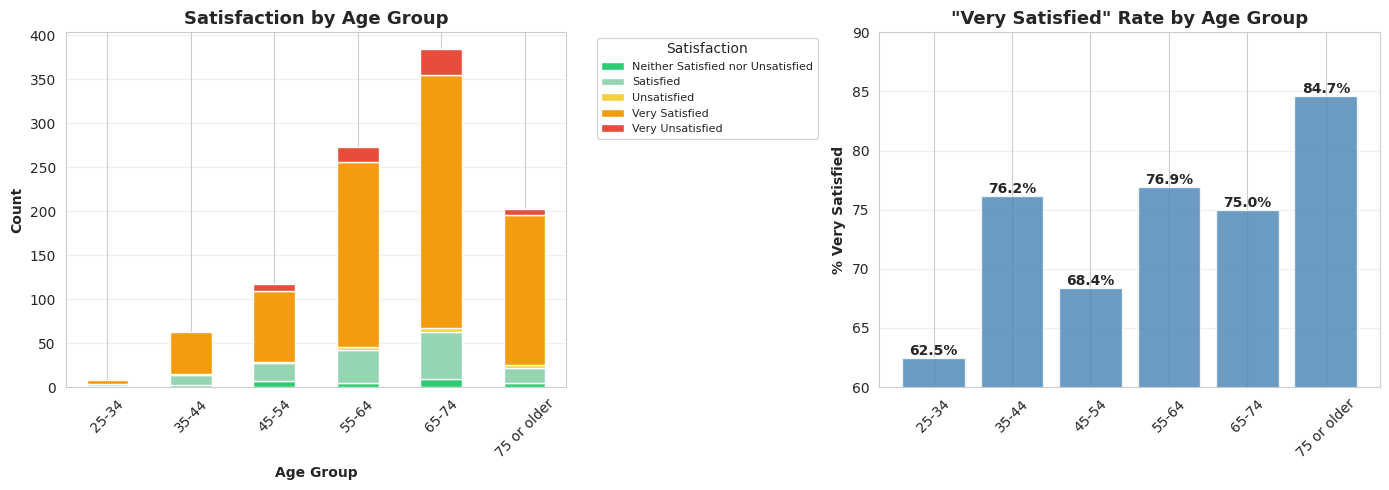

High Satisfaction % by Age:
Age
25-34          62.500000
35-44          76.190476
45-54          68.376068
55-64          76.923077
65-74          75.000000
75 or older    84.653465
Name: HighSatisfaction, dtype: float64


In [24]:
# Additional Analysis 3: Age vs Satisfaction breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction by age group
ax = axes[0]
age_sat = pd.crosstab(df_clean['Age'], df_clean['Satisfaction'])
age_order = ['25-34', '35-44', '45-54', '55-64', '65-74', '75 or older']
age_sat = age_sat.reindex([a for a in age_order if a in age_sat.index])

age_sat.plot(kind='bar', stacked=True, ax=ax,
             color=['#2ECC71', '#95D5B2', '#F4D03F', '#F39C12', '#E74C3C'])
ax.set_xlabel('Age Group', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Satisfaction by Age Group', fontweight='bold', fontsize=13)
ax.legend(title='Satisfaction', bbox_to_anchor=(1.05, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# High satisfaction percentage by age
ax = axes[1]
high_sat_age = df_clean.groupby('Age')['HighSatisfaction'].mean() * 100
high_sat_age = high_sat_age.reindex([a for a in age_order if a in high_sat_age.index])

bars = ax.bar(range(len(high_sat_age)), high_sat_age.values,
              color='steelblue', alpha=0.8)
ax.set_xticks(range(len(high_sat_age)))
ax.set_xticklabels(high_sat_age.index, rotation=45)
ax.set_ylabel('% Very Satisfied', fontweight='bold')
ax.set_title('"Very Satisfied" Rate by Age Group', fontweight='bold', fontsize=13)
ax.set_ylim([60, 90])
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig8_age_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

print("High Satisfaction % by Age:")
print(high_sat_age)

Gaussian Naive Bayes: 0.7460
KNN (k=3): 0.6794
Decision Tree: 0.7206
Random Forest: 0.7206


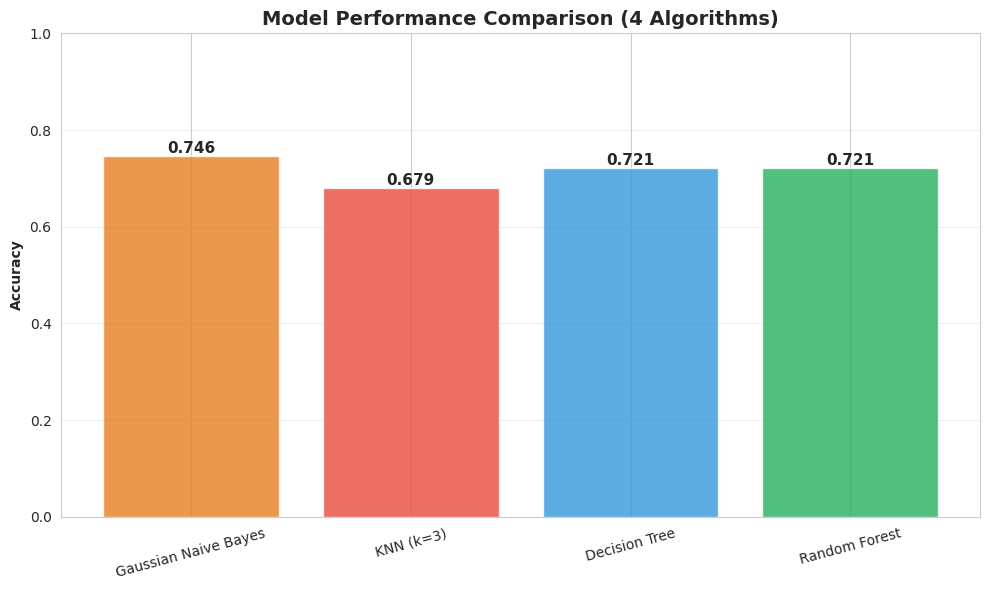

In [25]:
# Add Gaussian Naive Bayes to comparison
from sklearn.naive_bayes import GaussianNB

# Retrain all models including GNB
models_complete = {
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
}

results_complete = {}
for name, model in models_complete.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_complete[name] = {
        'accuracy': acc,
        'predictions': y_pred
    }
    print(f"{name}: {acc:.4f}")

# Updated comparison chart
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results_complete.keys())
accuracies = [results_complete[m]['accuracy'] for m in model_names]

bars = ax.bar(model_names, accuracies,
              color=['#E67E22', '#E74C3C', '#3498DB', '#27AE60'], alpha=0.8)
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Model Performance Comparison (4 Algorithms)', fontweight='bold', fontsize=14)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig9_model_comparison_complete.png', dpi=300, bbox_inches='tight')
plt.show()

5-FOLD CROSS-VALIDATION RESULTS:

Gaussian Naive Bayes:
  Fold scores: ['0.781', '0.743', '0.751', '0.770', '0.761']
  Mean: 0.7612 (+/- 0.0135)

KNN (k=3):
  Fold scores: ['0.657', '0.695', '0.689', '0.746', '0.703']
  Mean: 0.6982 (+/- 0.0287)

Decision Tree:
  Fold scores: ['0.771', '0.733', '0.751', '0.761', '0.751']
  Mean: 0.7536 (+/- 0.0126)

Random Forest:
  Fold scores: ['0.771', '0.757', '0.751', '0.756', '0.746']
  Mean: 0.7564 (+/- 0.0084)


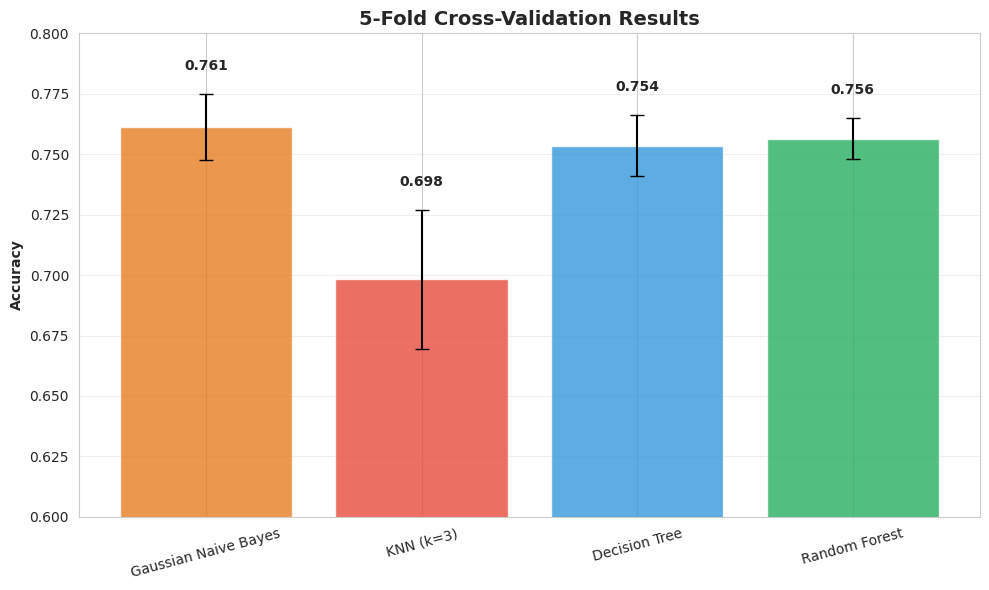


Best model (CV): Gaussian Naive Bayes


In [26]:
# Cross-validation evaluation (5-fold like HW5)
from sklearn.model_selection import cross_val_score

print("5-FOLD CROSS-VALIDATION RESULTS:")
print("="*70)

cv_results = {}

for name, model in models_complete.items():
    # 5-fold CV
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }

    print(f"\n{name}:")
    print(f"  Fold scores: {[f'{s:.3f}' for s in scores]}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in model_names]
stds = [cv_results[m]['std'] for m in model_names]

x = range(len(model_names))
bars = ax.bar(x, means, yerr=stds, capsize=5,
              color=['#E67E22', '#E74C3C', '#3498DB', '#27AE60'], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold', fontsize=14)
ax.set_ylim([0.6, 0.8])
ax.grid(axis='y', alpha=0.3)

for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax.text(i, mean + std + 0.01, f'{mean:.3f}',
           ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig10_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Best model (CV): " + max(cv_results, key=lambda k: cv_results[k]['mean']))

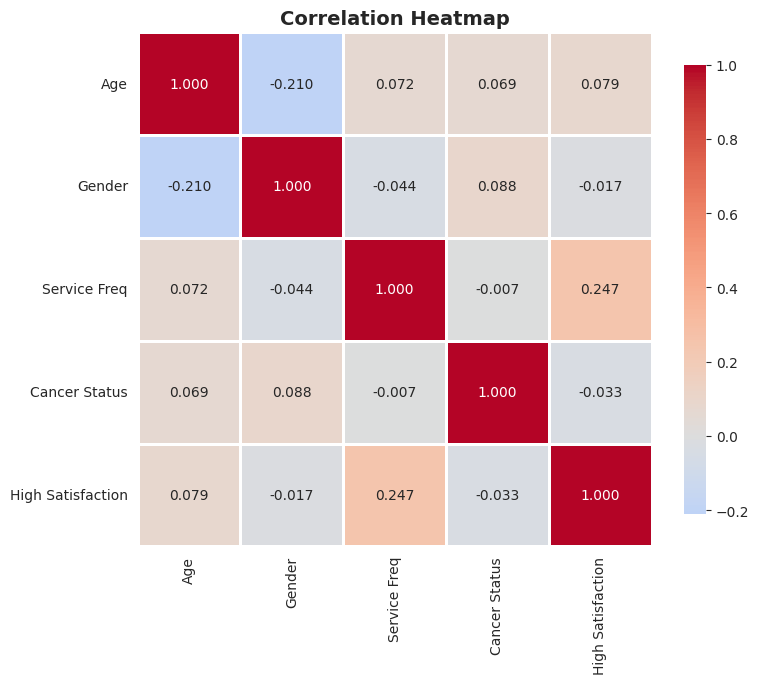

Correlation with High Satisfaction:
HighSatisfaction    1.000000
Freq_encoded        0.246882
Age_encoded         0.078612
Gender_encoded     -0.017014
Cancer_encoded     -0.032733
Name: HighSatisfaction, dtype: float64


In [27]:
# Correlation Analysis
# Create numeric version of key variables
df_corr = df_ml[['Age_encoded', 'Gender_encoded', 'Freq_encoded',
                  'Cancer_encoded', 'HighSatisfaction']].copy()

# Calculate correlation
corr_matrix = df_corr.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            xticklabels=['Age', 'Gender', 'Service Freq', 'Cancer Status', 'High Satisfaction'],
            yticklabels=['Age', 'Gender', 'Service Freq', 'Cancer Status', 'High Satisfaction'],
            ax=ax)

ax.set_title('Correlation Heatmap', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('fig11_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation with High Satisfaction:")
print(corr_matrix['HighSatisfaction'].sort_values(ascending=False))

PCA RESULTS:

Variance explained by each PC:
  PC1: 30.99%
  PC2: 26.19%
  PC3: 24.32%
  PC4: 18.50%

Cumulative variance:
  PC1-1: 30.99%
  PC1-2: 57.17%
  PC1-3: 81.50%


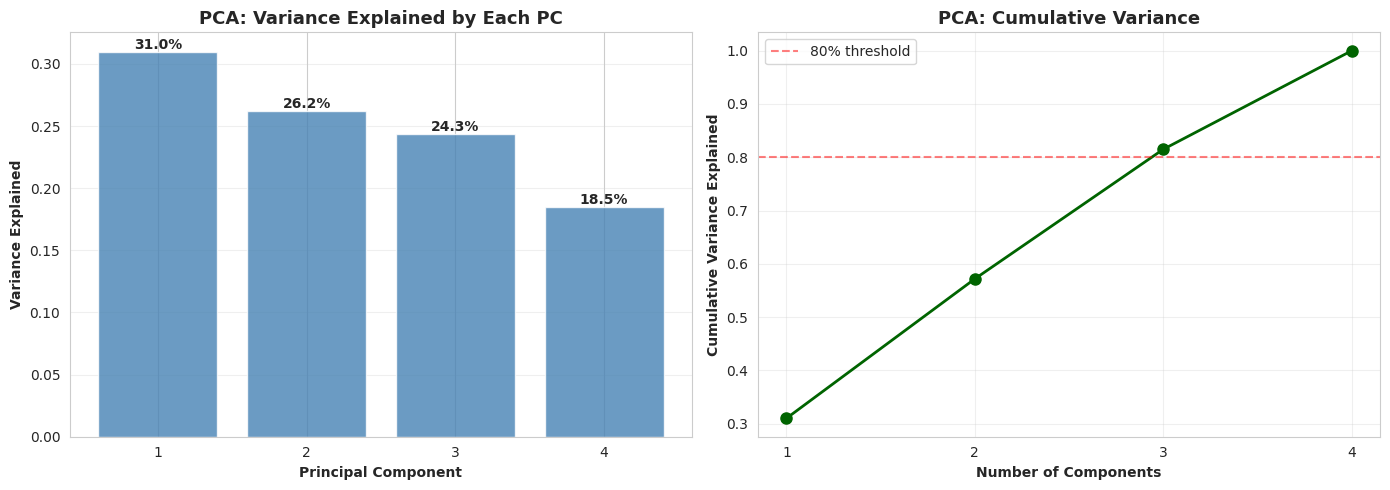


PC Loadings:
       Age  Gender  Service Freq  Cancer Status
PC1 -0.667   0.668        -0.324          0.063
PC2  0.303   0.262         0.092          0.912
PC3 -0.204   0.262         0.938         -0.102
PC4  0.650   0.646        -0.082         -0.393


In [28]:
# PCA on encoded features
from sklearn.decomposition import PCA

# Standardize features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance explained
explained_var = pca.explained_variance_ratio_

print("PCA RESULTS:")
print("="*70)
print("\nVariance explained by each PC:")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var*100:.2f}%")

cumulative = np.cumsum(explained_var)
print(f"\nCumulative variance:")
for i in range(min(3, len(cumulative))):
    print(f"  PC1-{i+1}: {cumulative[i]*100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, len(explained_var)+1), explained_var, color='steelblue', alpha=0.8)
ax.set_xlabel('Principal Component', fontweight='bold')
ax.set_ylabel('Variance Explained', fontweight='bold')
ax.set_title('PCA: Variance Explained by Each PC', fontweight='bold', fontsize=13)
ax.set_xticks(range(1, len(explained_var)+1))
for i, v in enumerate(explained_var):
    ax.text(i+1, v, f'{v*100:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Cumulative variance
ax = axes[1]
ax.plot(range(1, len(cumulative)+1), cumulative, marker='o',
        linewidth=2, markersize=8, color='darkgreen')
ax.axhline(0.80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_xlabel('Number of Components', fontweight='bold')
ax.set_ylabel('Cumulative Variance Explained', fontweight='bold')
ax.set_title('PCA: Cumulative Variance', fontweight='bold', fontsize=13)
ax.set_xticks(range(1, len(cumulative)+1))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig12_pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# PC loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=['Age', 'Gender', 'Service Freq', 'Cancer Status'],
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

print("\nPC Loadings:")
print(loadings.round(3))

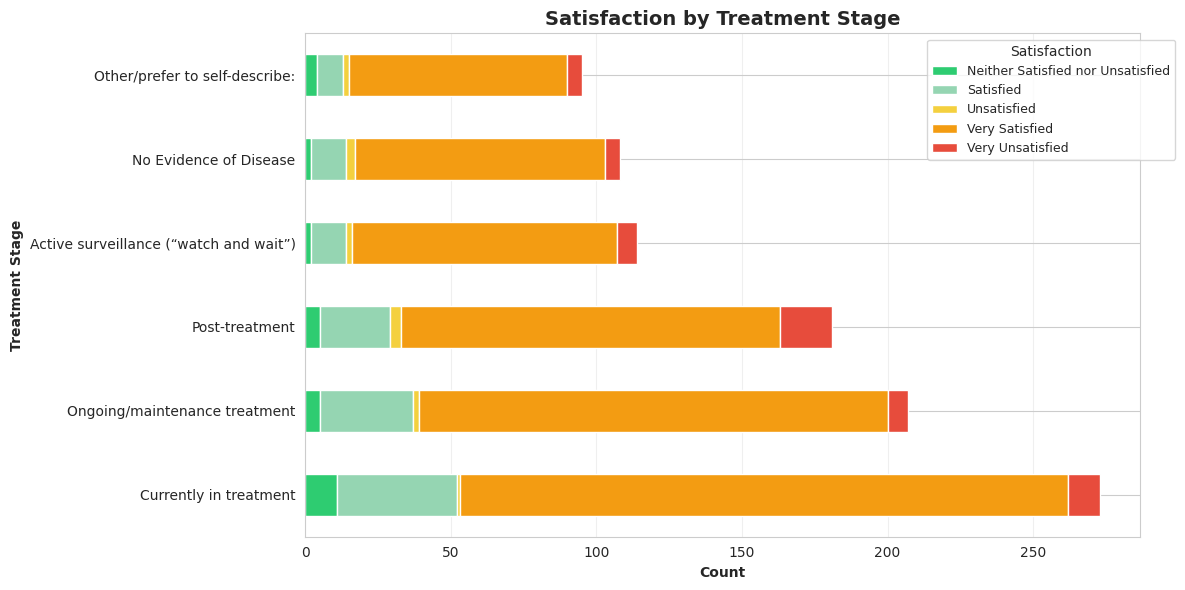

High Satisfaction % by Treatment Stage:
  Currently in treatment: 76.6%
  Ongoing/maintenance treatment: 77.8%
  Post-treatment: 71.8%
  Active surveillance (“watch and wait”): 79.8%
  No Evidence of Disease: 79.6%
  Other/prefer to self-describe:: 78.9%


In [29]:
# Treatment Stage vs Satisfaction
df_treatment = df_clean[df_clean['TreatmentStage'].notna()].copy()

# Get top treatment stages
top_treatments = df_treatment['TreatmentStage'].value_counts().head(6).index

df_treatment_top = df_treatment[df_treatment['TreatmentStage'].isin(top_treatments)]

fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bar by treatment stage
treat_sat = pd.crosstab(df_treatment_top['TreatmentStage'],
                        df_treatment_top['Satisfaction'])

treat_sat = treat_sat.reindex(top_treatments)

treat_sat.plot(kind='barh', stacked=True, ax=ax,
               color=['#2ECC71', '#95D5B2', '#F4D03F', '#F39C12', '#E74C3C'])

ax.set_xlabel('Count', fontweight='bold')
ax.set_ylabel('Treatment Stage', fontweight='bold')
ax.set_title('Satisfaction by Treatment Stage', fontweight='bold', fontsize=14)
ax.legend(title='Satisfaction', bbox_to_anchor=(1.05, 1), fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig13_treatment_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate high satisfaction rate by treatment
high_sat_treatment = df_treatment_top.groupby('TreatmentStage')['HighSatisfaction'].mean() * 100
high_sat_treatment = high_sat_treatment.reindex(top_treatments)

print("High Satisfaction % by Treatment Stage:")
for stage, pct in high_sat_treatment.items():
    print(f"  {stage[:50]}: {pct:.1f}%")